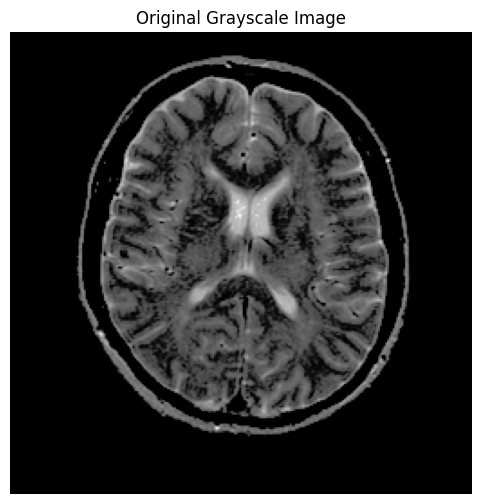

In [1]:
# CELL 1: Imports and Loading Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image in grayscale (0 flag)
# Note: Replace 'sample.jpg' with a path to your own image
image_path = 'mri.png'
original_image = cv2.imread(image_path, 0)

if original_image is None:
    # Creating a synthetic image for demonstration if no image is found
    print(f"Could not load {image_path}. Generating a synthetic image instead.")
    original_image = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(original_image, (100, 100), 50, 200, -1) # Bright circle
    original_image = original_image + np.random.normal(20, 10, (200, 200)).astype(np.uint8) # Add noise

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(original_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

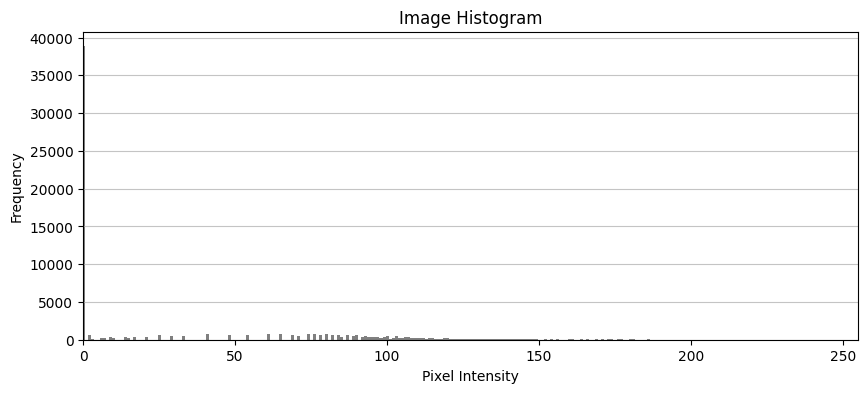

In [2]:
# CELL 2: Histogram Distribution Calculation
def compute_histogram(image):
    """Computes the histogram of a grayscale image from scratch."""
    hist = np.zeros(256, dtype=int)
    # Flatten the image to iterate through pixels easily
    flat_image = image.ravel()
    for pixel_value in flat_image:
        hist[pixel_value] += 1
    return hist

histogram = compute_histogram(original_image)

# Plotting the histogram
plt.figure(figsize=(10, 4))
plt.bar(range(256), histogram, color='gray', width=1)
plt.title('Image Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 255])
plt.grid(axis='y', alpha=0.75)
plt.show()

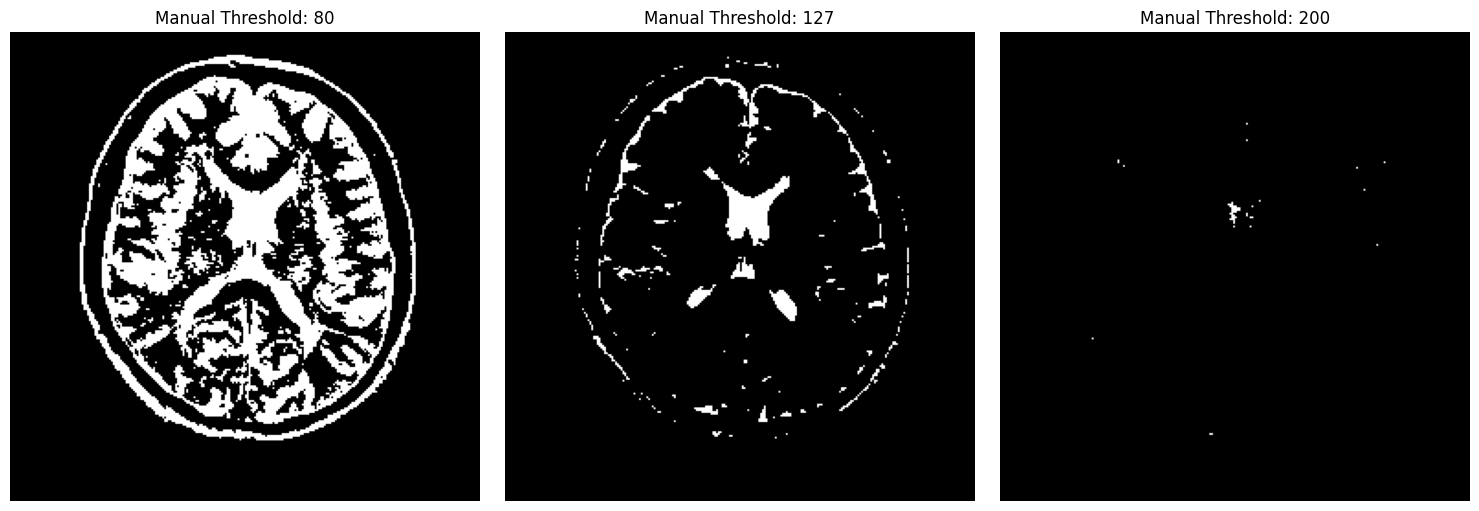

In [3]:
# CELL 3: Manual Thresholding Implementation
def manual_threshold(image, threshold_value):
    """Applies binary thresholding using basic numpy."""
    # Create an output array of zeros with the same shape as the input
    binary_img = np.zeros_like(image)
    # Set pixels greater than the threshold to 255 (white)
    binary_img[image > threshold_value] = 255
    return binary_img

# Let's pick 3 arbitrary thresholds to compare
T1, T2, T3 = 80, 127, 200

manual_res1 = manual_threshold(original_image, T1)
manual_res2 = manual_threshold(original_image, T2)
manual_res3 = manual_threshold(original_image, T3)

# Display the manual thresholding results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(manual_res1, cmap='gray')
axes[0].set_title(f'Manual Threshold: {T1}')
axes[0].axis('off')

axes[1].imshow(manual_res2, cmap='gray')
axes[1].set_title(f'Manual Threshold: {T2}')
axes[1].axis('off')

axes[2].imshow(manual_res3, cmap='gray')
axes[2].set_title(f'Manual Threshold: {T3}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# CELL 4: Otsu's Algorithm Implementation
def otsu_threshold(image, hist):
    """Calculates the optimal threshold using Otsu's method from scratch."""
    total_pixels = image.shape[0] * image.shape[1]
    
    # Calculate probabilities of each intensity level
    probabilities = hist / total_pixels
    
    best_threshold = 0
    max_variance = 0
    
    # Iterate through all possible thresholds t
    for t in range(256):
        # Weights (Probabilities of class 0 and class 1)
        w0 = np.sum(probabilities[:t+1])
        w1 = np.sum(probabilities[t+1:])
        
        # If either class has no pixels, we can't calculate a valid variance, so skip
        if w0 == 0 or w1 == 0:
            continue
            
        # Means (Expected value of class 0 and class 1)
        mu0 = np.sum(np.arange(t+1) * probabilities[:t+1]) / w0
        mu1 = np.sum(np.arange(t+1, 256) * probabilities[t+1:]) / w1
        
        # Between-class variance
        variance_between = w0 * w1 * (mu0 - mu1)**2
        
        # Keep track of the maximum variance and the threshold that caused it
        if variance_between > max_variance:
            max_variance = variance_between
            best_threshold = t
            
    return best_threshold

# Calculate the optimal threshold
optimal_T = otsu_threshold(original_image, histogram)
print(f"Calculated Optimal Threshold (Otsu's Method): {optimal_T}")

# Apply the calculated threshold
otsu_result = manual_threshold(original_image, optimal_T)

Calculated Optimal Threshold (Otsu's Method): 48


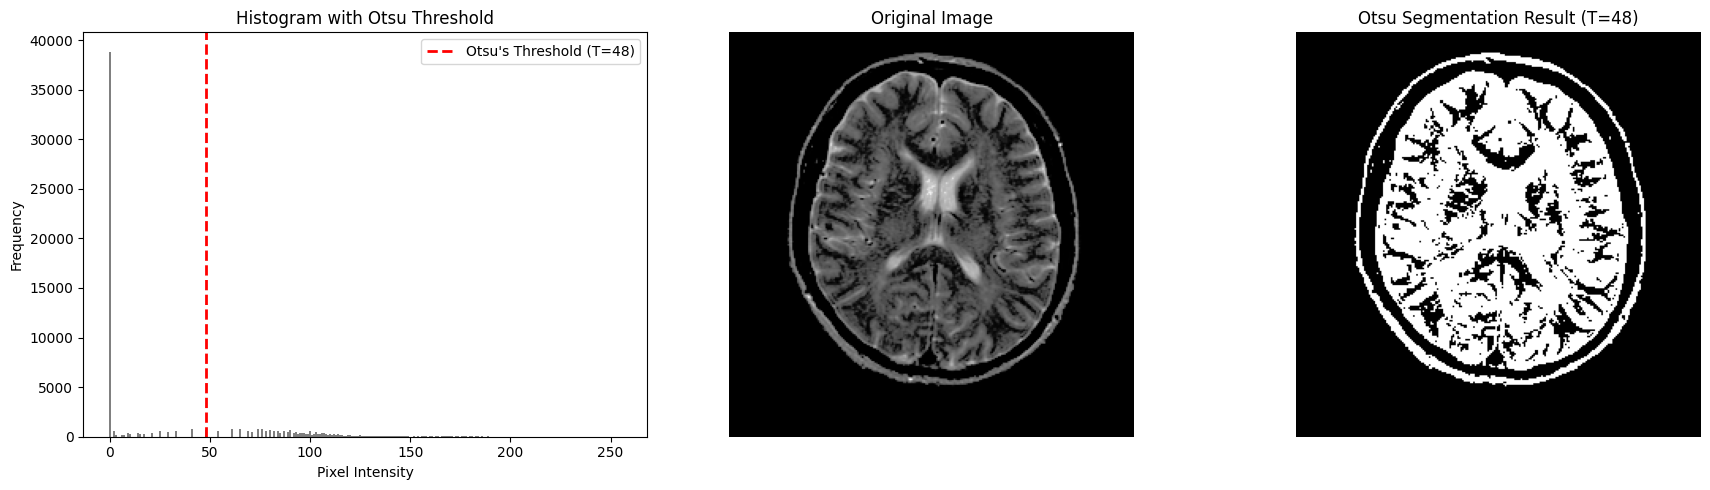

--- Segmentation Quality Comparison ---
Manual thresholding requires guessing or visually inspecting the histogram, which often fails if lighting changes.
Otsu's method automatically found T=48 by maximizing the variance between the foreground and background classes.
This usually provides the cleanest, mathematically optimal bimodal split without human intervention.


In [5]:
# CELL 5: Final Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Histogram with Otsu Threshold line
axes[0].bar(range(256), histogram, color='gray', width=1)
axes[0].axvline(optimal_T, color='red', linestyle='dashed', linewidth=2, 
                label=f"Otsu's Threshold (T={optimal_T})")
axes[0].set_title('Histogram with Otsu Threshold')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Original Image
axes[1].imshow(original_image, cmap='gray')
axes[1].set_title('Original Image')
axes[1].axis('off')

# Plot 3: Otsu Segmentation Result
axes[2].imshow(otsu_result, cmap='gray')
axes[2].set_title(f'Otsu Segmentation Result (T={optimal_T})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Conclusion on Segmentation Quality
print("--- Segmentation Quality Comparison ---")
print("Manual thresholding requires guessing or visually inspecting the histogram, which often fails if lighting changes.")
print(f"Otsu's method automatically found T={optimal_T} by maximizing the variance between the foreground and background classes.")
print("This usually provides the cleanest, mathematically optimal bimodal split without human intervention.")

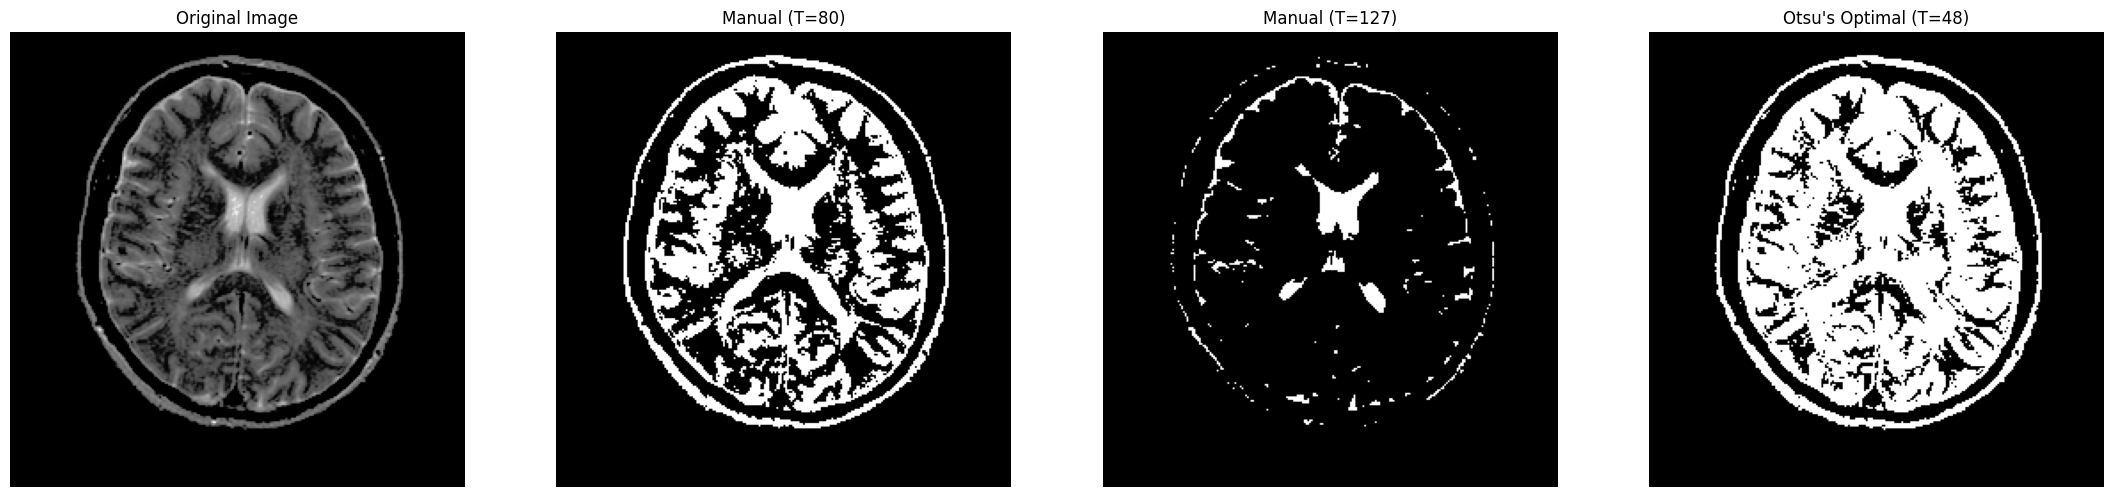

--- Final Segmentation Evaluation ---
1. Low Manual (T=80): Often leaves too much background noise (false positives).
2. Medium Manual (T=127): A decent guess, but might over/under segment depending on lighting.
4. Otsu (T=48): Automatically balances the trade-off by finding the exact mathematical valley in the histogram, yielding the most robust bimodal segmentation.


In [ ]:
# CELL 6: Comprehensive Visual Comparison
# Setting up a 1x5 grid to compare all thresholded images side-by-side
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1. Original
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# 2. Manual 1
axes[1].imshow(manual_res1, cmap='gray')
axes[1].set_title(f'Manual (T={T1})')
axes[1].axis('off')

# 3. Manual 2
axes[2].imshow(manual_res2, cmap='gray')
axes[2].set_title(f'Manual (T={T2})')
axes[2].axis('off')

# # 4. Manual 3
# axes[3].imshow(manual_res3, cmap='gray')
# axes[3].set_title(f'Manual (T={T3})')
# axes[3].axis('off')

# 5. Otsu
axes[3].imshow(otsu_result, cmap='gray')
axes[3].set_title(f"Otsu's Optimal (T={optimal_T})")
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Final Evaluation Printout
print("--- Final Segmentation Evaluation ---")
print(f"1. Low Manual (T={T1}): Often leaves too much background noise (false positives).")
print(f"2. Medium Manual (T={T2}): A decent guess, but might over/under segment depending on lighting.")
# print(f"3. High Manual (T={T3}): Usually erodes the foreground too much, losing important details (false negatives).")
print(f"3. Otsu (T={optimal_T}): Automatically balances the trade-off by finding the exact mathematical valley in the histogram, yielding the most robust bimodal segmentation.")

Calculated Optimal Threshold for Tissue (Masked Otsu): 81


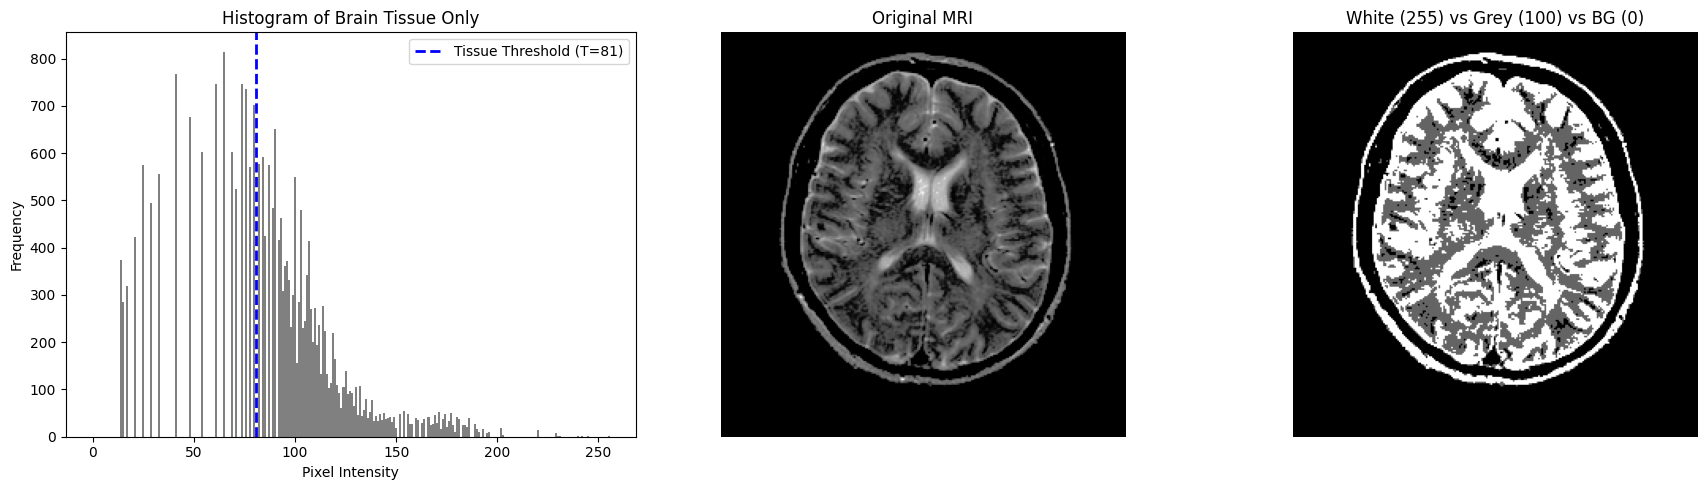

--- Masked Otsu Evaluation ---
By removing the massive spike of dark background pixels from our histogram,
Otsu's algorithm was able to find the subtle secondary valley between the
grey matter and the brighter white matter/fluids inside the brain.


In [10]:
# CELL 7: Masked Otsu for White vs. Grey Matter

# 1. Create a mask to isolate the brain. 
# We'll use a low threshold (e.g., > 10) to safely exclude the dark background noise.
brain_mask = original_image > 10

# 2. Extract only the pixel intensities of the brain
brain_pixels = original_image[brain_mask]

# 3. Compute the histogram of ONLY the brain tissue
masked_hist = np.zeros(256, dtype=int)
for pixel_value in brain_pixels:
    masked_hist[pixel_value] += 1

# 4. Modified Otsu to handle masked histograms
def masked_otsu_threshold(hist):
    """Calculates Otsu threshold based on a specific pixel count, not image dimensions."""
    total_pixels = np.sum(hist) # Use the sum of the histogram, not image shape
    probabilities = hist / total_pixels
    
    best_threshold = 0
    max_variance = 0
    
    for t in range(256):
        w0 = np.sum(probabilities[:t+1])
        w1 = np.sum(probabilities[t+1:])
        
        if w0 == 0 or w1 == 0:
            continue
            
        mu0 = np.sum(np.arange(t+1) * probabilities[:t+1]) / w0
        mu1 = np.sum(np.arange(t+1, 256) * probabilities[t+1:]) / w1
        
        variance_between = w0 * w1 * (mu0 - mu1)**2
        
        if variance_between > max_variance:
            max_variance = variance_between
            best_threshold = t
            
    return best_threshold

# Calculate the new threshold for the brain tissue only
brain_optimal_T = masked_otsu_threshold(masked_hist)
print(f"Calculated Optimal Threshold for Tissue (Masked Otsu): {brain_optimal_T}")

# 5. Apply the threshold to separate White Matter, Grey Matter, and Background
# Create an output array of zeros (Background = 0/Black)
tissue_segmented = np.zeros_like(original_image)

# White matter: Part of the brain AND above the new tissue threshold
tissue_segmented[(brain_mask) & (original_image > brain_optimal_T)] = 255

# Grey matter: Part of the brain AND below the new tissue threshold
# We'll set this to a medium gray (e.g., 100) so we can see all 3 classes
tissue_segmented[(brain_mask) & (original_image <= brain_optimal_T)] = 100

# 6. Display the results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Masked Histogram
axes[0].bar(range(256), masked_hist, color='gray', width=1)
axes[0].axvline(brain_optimal_T, color='blue', linestyle='dashed', linewidth=2, 
                label=f"Tissue Threshold (T={brain_optimal_T})")
axes[0].set_title('Histogram of Brain Tissue Only')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Original Image
axes[1].imshow(original_image, cmap='gray')
axes[1].set_title('Original MRI')
axes[1].axis('off')

# Plot 3: Segmented Tissues
axes[2].imshow(tissue_segmented, cmap='gray')
axes[2].set_title(f'White (255) vs Grey (100) vs BG (0)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Conclusion
print("--- Masked Otsu Evaluation ---")
print("By removing the massive spike of dark background pixels from our histogram,")
print("Otsu's algorithm was able to find the subtle secondary valley between the")
print("grey matter and the brighter white matter/fluids inside the brain.")